# FastSHAP

In [67]:
import numpy as np
import torch
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.special import comb
from torch.utils.data import DataLoader, TensorDataset

# =====================
# 1. Enhanced Model Training with Early Stopping
# =====================
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


class SurrogateModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1))
        
    def forward(self, x):
        return self.net(x).squeeze()
    
    def predict(self, X):
        with torch.no_grad():
            return self(torch.FloatTensor(X)).numpy()


def train_surrogate(model, X_train, y_train, device='cpu', 
                    n_epochs=1000, batch_size=256, patience=10):
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
    
    train_dataset = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    early_stopping = EarlyStopping(patience=patience)
    
    model.to(device)
    
    for epoch in range(n_epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            val_preds = model(torch.FloatTensor(X_val).to(device)).cpu()
            val_loss = criterion(val_preds, torch.FloatTensor(y_val)).item()
        
        print(f"Epoch {epoch+1}: Train Loss {train_loss/len(train_loader):.4f}, Val Loss {val_loss:.4f}")
        
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break
            
    return model


# =====================
# 2. FastSHAP with Optimized Sampling
# =====================
class FastSHAPExplainer(nn.Module):
    def __init__(self, input_size, hidden_size=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size))
        
    def forward(self, x):
        return self.net(x)
    
    def explain(self, X, baseline_input, surrogate_model, device='cpu'):
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(device)
            baseline_tensor = torch.FloatTensor(baseline_input).to(device)
            
            # Calculate baseline value
            v0 = surrogate_model(baseline_tensor.unsqueeze(0)).cpu().item()
            
            # Get SHAP values
            phi = self(X_tensor)
            
            # Efficiency constraint enforcement
            v1 = surrogate_model(X_tensor).cpu().numpy()
            gap = (v1 - v0 - phi.sum(dim=1).cpu().numpy()) / X.shape[1]
            return phi.cpu().numpy() + gap[:, np.newaxis]

def get_shapley_weights(n_features):
    """Improved Shapley kernel weight calculation"""
    weights = np.zeros(n_features + 1)
    for k in range(n_features + 1):
        if k == 0 or k == n_features:
            weights[k] = 1e-6  # Avoid division by zero
        else:
            weights[k] = (n_features - 1) / (k * (n_features - k) * comb(n_features, k))
    return weights / weights.sum()

def generate_masks(batch_size, n_features, weights, device='cpu'):
    """Optimized mask generation with full subset coverage"""
    # Sample subset sizes including 0 and n_features
    subset_sizes = np.random.choice(np.arange(n_features + 1), size=batch_size, p=weights)
    
    # Generate masks using vectorized operations
    random_matrix = np.random.rand(batch_size, n_features)
    sorted_indices = np.argsort(random_matrix, axis=1)
    
    masks = np.zeros((batch_size, n_features), dtype=np.float32)
    row_indices = np.arange(batch_size)[:, None]
    
    # Vectorized mask assignment
    for k in range(n_features + 1):
        mask = subset_sizes == k
        if k > 0:
            masks[mask, sorted_indices[mask, :k]] = 1
            
    return torch.from_numpy(masks).to(device)


# =====================
# 3. Training Process
# =====================
# Generate data
# n_samples, n_features = 10000, 20
# X = np.random.randn(n_samples, n_features)
# y = 3*X[:,0] + 2*X[:,1] + np.random.randn(n_samples)*0.5
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

# Original data
# =====================
# 3. Training Process
# =====================
# Generate data
n_samples, n_features = 10000, 20
X = np.random.randn(n_samples, n_features)
y = 3 * X[:, 0] + 2 * X[:, 1] + np.random.randn(n_samples) * 0.5

# 1. Add Interaction Terms
interaction_terms = X[:, 0] * X[:, 1]  # Interaction between feature 0 and feature 1
X = np.column_stack((X, interaction_terms))

# 2. Add Non-linear Transformations
non_linear_features = np.sin(X[:, 2]) + np.log(np.abs(X[:, 3]) + 1)  # Non-linear transformations
X = np.column_stack((X, non_linear_features))

# 3. Add Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X[:, :5])  # Apply polynomial features to the first 5 features
X = np.column_stack((X, X_poly[:, 5:]))  # Append the new polynomial features

# 4. Add Noise to Features
noise = np.random.randn(n_samples, 5) * 0.1  # Add noise to 5 new features
X = np.column_stack((X, noise))

# 5. Add Redundant Features
redundant_features = X[:, 0] + X[:, 1]  # Redundant feature as a linear combination of feature 0 and 1
X = np.column_stack((X, redundant_features))

# 6. Add Categorical Features
categorical_features = np.random.choice([0, 1, 2], size=(n_samples, 2))  # Two categorical features
X = np.column_stack((X, categorical_features))

# 7. Add Missing Values
missing_mask = np.random.rand(*X.shape) < 0.05  # 5% missing values
X[missing_mask] = np.nan

# Impute missing values in X
imputer = SimpleImputer(strategy='mean')  # Use mean imputation
X_imputed = imputer.fit_transform(X)

# Update the target variable to reflect the new complexity
y = 3 * X_imputed[:, 0] + 2 * X_imputed[:, 1] + 1.5 * X_imputed[:, 20] + 0.5 * X_imputed[:, 21] + np.random.randn(n_samples) * 0.5

# Now X has more features and is more complex
print(X_imputed.shape)  # Should have more than 20 features now
print(y.shape)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"\nRandom Forest R²: {r2_score(y_test, y_pred):.4f}")

# Train surrogate model
input_size = X_imputed.shape[1]  # Number of features in the updated dataset
surrogate = SurrogateModel(input_size)
surrogate = train_surrogate(surrogate, X_train, rf.predict(X_train), 
                           device='cuda' if torch.cuda.is_available() else 'cpu')

# Initialize FastSHAP
device = 'cuda' if torch.cuda.is_available() else 'cpu'
explainer = FastSHAPExplainer(input_size, hidden_size=256).to(device)
optimizer = torch.optim.Adam(explainer.parameters(), lr=0.001)
shapley_weights = get_shapley_weights(input_size)
baseline = np.mean(X_train, axis=0)

# Training loop with early stopping
train_dataset = TensorDataset(torch.FloatTensor(X_train))
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
early_stopping = EarlyStopping(patience=7, delta=0.001)
best_loss = np.inf

for epoch in range(100):
    explainer.train()
    epoch_loss = 0
    
    for X_batch in train_loader:
        X_batch = X_batch[0].to(device)
        batch_size = X_batch.size(0)
        
        # Generate masks vectorized
        masks = generate_masks(batch_size, input_size, shapley_weights, device)
        
        # Get predictions
        with torch.no_grad():
            masked_inputs = X_batch * masks + torch.FloatTensor(baseline).to(device) * (1 - masks)
            masked_preds = surrogate(masked_inputs)
            baseline_pred = surrogate(torch.FloatTensor(baseline).to(device).repeat(batch_size, 1))
            
        # Calculate loss
        phi = explainer(X_batch)
        loss = ((masked_preds - baseline_pred - (masks * phi).sum(dim=1)) ** 2).mean()
        
        # Efficiency regularization
        full_preds = surrogate(X_batch)
        efficiency_loss = ((full_preds - baseline_pred - phi.sum(dim=1)) ** 2).mean()
        
        total_loss = loss + 0.1 * efficiency_loss
        
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        epoch_loss += total_loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}: Loss {avg_loss:.4f}")
    
    early_stopping(avg_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# =====================
# 4. Explanation & Comparison
# =====================
# Get explanations
fast_shap_values = explainer.explain(X_test[:1000], baseline, device=device)

# Compare with TreeSHAP
explainer_tree = shap.TreeExplainer(rf)
shap_values_tree = explainer_tree.shap_values(X_test[:1000])

print("\nComparison Metrics:")
print(f"MAE between methods: {np.mean(np.abs(fast_shap_values - shap_values_tree)):.4f}")
print(f"Correlation: {np.corrcoef(fast_shap_values.ravel(), shap_values_tree.ravel())[0,1]:.4f}")
print(f"Efficiency error: {np.mean(np.abs(fast_shap_values.sum(1) - (rf.predict(X_test[:1000]) - explainer_tree.expected_value))):.4f}")

# =====================
# 5. Usage Example
# =====================
# Get predictions from surrogate model
surrogate_preds = surrogate.predict(X_test)

# Explain new instances
sample = X_test[:1]
explanations = explainer.explain(sample, baseline, device=device)
tree_explanations = explainer_tree.shap_values(sample)

print("\nSample explanations:")
print(explanations)
print(tree_explanations)


(10000, 45)
(10000,)

Random Forest R²: 0.9677
Epoch 1: Train Loss 12.4235, Val Loss 9.1690
Epoch 2: Train Loss 3.8753, Val Loss 0.9163
Epoch 3: Train Loss 0.7829, Val Loss 0.5831
Epoch 4: Train Loss 0.5241, Val Loss 0.4474
Epoch 5: Train Loss 0.4271, Val Loss 0.3808
Epoch 6: Train Loss 0.3512, Val Loss 0.3164
Epoch 7: Train Loss 0.2911, Val Loss 0.2731
Epoch 8: Train Loss 0.2439, Val Loss 0.2359
Epoch 9: Train Loss 0.2098, Val Loss 0.2069
Epoch 10: Train Loss 0.1847, Val Loss 0.1881
Epoch 11: Train Loss 0.1717, Val Loss 0.1783
Epoch 12: Train Loss 0.1610, Val Loss 0.1750
Epoch 13: Train Loss 0.1590, Val Loss 0.1728
Epoch 14: Train Loss 0.1460, Val Loss 0.1713
Epoch 15: Train Loss 0.1390, Val Loss 0.1663
Epoch 16: Train Loss 0.1360, Val Loss 0.1662
Epoch 17: Train Loss 0.1328, Val Loss 0.1655
Epoch 18: Train Loss 0.1324, Val Loss 0.1654
Epoch 19: Train Loss 0.1280, Val Loss 0.1654
Epoch 20: Train Loss 0.1269, Val Loss 0.1646
Epoch 21: Train Loss 0.1229, Val Loss 0.1651
Epoch 22: Train 

## Plot Result

  0%|          | 0/1 [00:00<?, ?it/s]

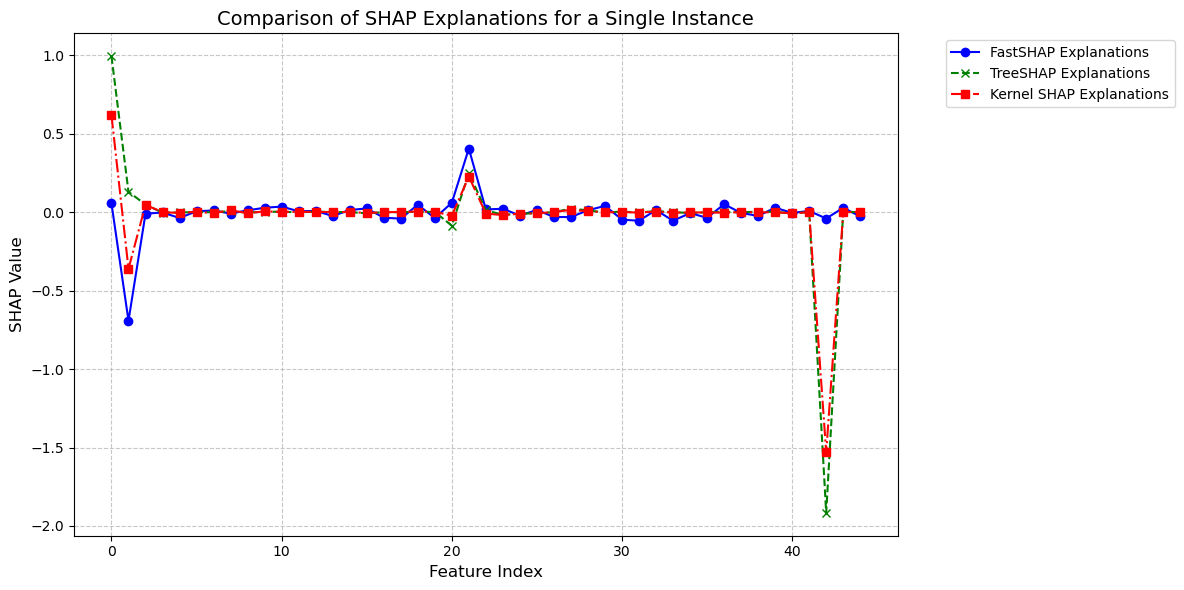

In [137]:
import matplotlib.pyplot as plt
import numpy as np

explainer_kernel = shap.KernelExplainer(rf.predict, X_train[:100])  # Use a subset of training data for background

# Explain new instances
i = np.random.randint(0, 100, 1, dtype=int)[0]
sample = X_test[i:i+1]
explanations = explainer.explain(sample, baseline, device=device)
tree_explanations = explainer_tree.shap_values(sample)
explanations_kernelshap = explainer_kernel.shap_values(sample)

# Create x-axis values (indices)
x = np.arange(len(explanations[0]))

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(x, explanations[0], label="FastSHAP Explanations", marker='o', linestyle='-', color='blue')
plt.plot(x, tree_explanations[0], label="TreeSHAP Explanations", marker='x', linestyle='--', color='green')
plt.plot(x, explanations_kernelshap[0], label="Kernel SHAP Explanations", marker='s', linestyle='-.', color='red')

# Add labels and title
plt.xlabel("Feature Index", fontsize=12)
plt.ylabel("SHAP Value", fontsize=12)
plt.title("Comparison of SHAP Explanations for a Single Instance", fontsize=14)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

# FastSHAP 2D

In [ ]:
from Functions import main
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sequence_length = 48
n_features = 10
n_pred_steps = 1  # Predict next hour
l1_lambda = 0.01  # L1 regularization strength

# Generate synthetic data
def generate_synthetic_data(n_samples=10000):
    X = np.random.randn(n_samples, sequence_length, n_features)
    y = X[:, -1, 0] * 0.5 + X[:, -2, 5] * 0.3 + np.random.randn(n_samples) * 0.1
    return X, y

# Temporal Convolutional Network (TCN) Components
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                              padding=(kernel_size//2)*dilation, dilation=dilation)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 
                              padding=(kernel_size//2)*dilation, dilation=dilation)
        self.relu = nn.ReLU()
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        residual = x
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        if self.downsample:
            residual = self.downsample(residual)
        return self.relu(out + residual)

class TCNSurrogate(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn = nn.Sequential(
            ResidualBlock(n_features, 32),
            ResidualBlock(32, 64),
            ResidualBlock(64, 128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.predictor = nn.Linear(128, n_pred_steps)
        
    def forward(self, x):
        x = x.permute(0, 2, 1)  # [batch, features, time]
        features = self.tcn(x).squeeze(-1)
        return self.predictor(features).squeeze()

class TCNExplainer(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn = nn.Sequential(
            ResidualBlock(n_features, 32),
            ResidualBlock(32, 64),
            nn.Conv1d(64, 1, kernel_size=1)  # Output importance per timestep
        )
        
    def forward(self, x):
        x = x.permute(0, 2, 1)  # [batch, features, time]
        importance = self.tcn(x)  # [batch, 1, time]
        return importance.permute(0, 2, 1)  # [batch, time, 1]

# Training Functions
def train_tcn_shap(dataset_type, model_type, X_train, y_train):
    # Convert to tensors
    X_tensor = torch.FloatTensor(X_train).to(device)
    y_tensor = torch.FloatTensor(y_train).to(device)
    train_dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    # Initialize models
    surrogate = TCNSurrogate().to(device)
    explainer = TCNExplainer().to(device)
    
    # Optimizers
    sur_optim = optim.Adam(surrogate.parameters(), lr=0.001)
    exp_optim = optim.Adam(explainer.parameters(), lr=0.0005)
    
    # Training loop
    for epoch in range(100):
        surrogate.train()
        explainer.train()
        
        epoch_loss = 0
        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            # Train surrogate
            sur_optim.zero_grad()
            preds = surrogate(X_batch)
            loss = nn.MSELoss()(preds, y_batch)
            loss.backward()
            sur_optim.step()
            
            # Train explainer with L1 regularization
            exp_optim.zero_grad()
            importance = explainer(X_batch)
            
            # Create masked inputs
            masks = torch.sigmoid(importance)  # [batch, time, 1]
            masked_inputs = X_batch * masks
            
            # Calculate loss components
            preds_masked = surrogate(masked_inputs)
            recon_loss = nn.MSELoss()(preds_masked, y_batch)
            l1_loss = torch.norm(importance, 1)
            total_loss = recon_loss + l1_lambda * l1_loss
            
            total_loss.backward()
            exp_optim.step()
            
            epoch_loss += total_loss.item()
        
        print(f"Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.4f}")
    
    return surrogate, explainer

# Visualization
def plot_temporal_importance(importance, sample, feature_names):
    """Plot temporal importance heatmap with actual feature values"""
    plt.figure(figsize=(16, 8))
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # Importance heatmap
    sns.heatmap(importance.T, ax=ax1, cmap='viridis', 
                yticklabels=feature_names,
                xticklabels=np.arange(sequence_length),
                cbar_kws={'label': 'Importance Score'})
    ax1.set_title("Temporal Feature Importance")
    ax1.set_xlabel("Time Steps")
    ax1.set_ylabel("Features")
    
    # Feature values heatmap
    sns.heatmap(sample.T, ax=ax2, cmap='coolwarm',
                yticklabels=feature_names,
                xticklabels=np.arange(sequence_length),
                cbar_kws={'label': 'Feature Value'})
    ax2.set_title("Actual Feature Values")
    ax2.set_xlabel("Time Steps")
    ax2.set_ylabel("Features")
    
    plt.tight_layout()
    plt.show()

# Example Usage
if __name__ == "__main__":
    # Generate synthetic data
    X, y = generate_synthetic_data(10000)
    feature_names = ['Hour', 'DayOfWeek', 'DayOfMonth', 'Month', 'DayOfYear', 
                    'IsWeekend', 'temperature', 'humidity', 'wind_speed', 'energy_consumption']
    
    # Train models
    surrogate, explainer = train_tcn_shap("Residential", "TCN", X, y)
    
    # Generate explanation for a sample
    sample = X[0:1]  # Get first sample
    with torch.no_grad():
        importance = explainer(torch.FloatTensor(sample).to(device)).cpu().numpy()[0]
    
    # Plot results
    plot_temporal_importance(importance, sample[0], feature_names)